In [1]:
# Imports principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from skimage.io import imread
from skimage.transform import resize
from collections import Counter

# Modelos y métricas
from sklearn.model_selection import train_test_split, learning_curve, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.pipeline import Pipeline

# --- CLASIFICADORES ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Para distribuciones de Random Search
from scipy.stats import randint, uniform

In [2]:
# Celda 1: Función para cargar imágenes
def load_image_dataset(root_dir, size=(64,64), max_per_class=None):
    X, y = [], []
    classes = sorted(os.listdir(root_dir))
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg'))]
        if max_per_class:
            files = files[:max_per_class]
        for f in files:
            img = imread(os.path.join(cls_path, f))
            if img.ndim == 3:  # convertir a escala de grises si es RGB
                img = img[...,0]
            img_resized = resize(img, size, anti_aliasing=True)
            X.append(img_resized)
            y.append(cls)
    return np.array(X), np.array(y), classes

# Celda 2: Carga, normalización y división de datos
# Cambia la ruta por la carpeta donde tengas las imágenes
X, y, classes = load_image_dataset("CMS_data", size=(64,64))
print("Datos cargados.")
print(f"Clases: {classes}")

# Normalizar al rango [0,1]
X = X / X.max()

# Aplanar imágenes para modelos clásicos
X_flat = X.reshape(len(X), -1)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Datos cargados.
Clases: ['electron', 'muon', 'neutrino', 'proton', 'quark', 'tau']
Train: (48000, 4096), Test: (12000, 4096)


In [3]:
# Binarizar las etiquetas (necesario para ROC multiclase)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]
print(f"Número de clases binarizadas: {n_classes}")

Número de clases binarizadas: 6


In [4]:
# --- Función para graficar ROC ---
def plot_multiclass_roc(y_test_bin, y_score, classes, title):
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# --- Función para graficar Curvas de Aprendizaje ---
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Ejemplos de entrenamiento")
    plt.ylabel("Score (Accuracy)")
    
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="accuracy"
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True)
    
    plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r",
             label="Score de Entrenamiento (Train)")
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g",
             label="Score de Validación (Test/CV)")
    
    plt.legend(loc="best")
    plt.show()

In [5]:
print("Iniciando RandomizedSearch para Random Forest...")

# Definimos el modelo y las distribuciones de parámetros
rf_model = RandomForestClassifier(random_state=42)
param_dist_rf = {
    'n_estimators': randint(100, 300),       # Número de árboles (un entero aleatorio entre 100 y 300)
    'max_depth': [10, 20, 30, None],         # Profundidad máxima (elegir uno de esta lista)
    'min_samples_leaf': randint(1, 10)       # Mínimo de muestras por hoja
}

# n_iter=10: Probará 10 combinaciones aleatorias.
# cv=3 para hacerlo más rápido.
random_rf = RandomizedSearchCV(
    rf_model, 
    param_distributions=param_dist_rf, 
    n_iter=10, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1, 
    random_state=42, 
    verbose=1
)
random_rf.fit(X_train, y_train)

# Obtenemos el mejor modelo
best_rf = random_rf.best_estimator_
print(f"Mejores parámetros para RF: {random_rf.best_params_}")

Iniciando RandomizedSearch para Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores parámetros para RF: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 260}


In [6]:
print("--- Reporte de Clasificación (Random Forest) ---")
y_pred_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=classes))

--- Reporte de Clasificación (Random Forest) ---
              precision    recall  f1-score   support

    electron       0.74      0.48      0.58      2000
        muon       0.60      0.55      0.58      2000
    neutrino       0.70      0.83      0.76      2000
      proton       0.96      0.99      0.98      2000
       quark       0.89      1.00      0.94      2000
         tau       0.75      0.83      0.79      2000

    accuracy                           0.78     12000
   macro avg       0.78      0.78      0.77     12000
weighted avg       0.78      0.78      0.77     12000



In [7]:
print("--- Reporte de Clasificación (Random Forest) ---")
y_pred_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=classes))

--- Reporte de Clasificación (Random Forest) ---
              precision    recall  f1-score   support

    electron       0.74      0.48      0.58      2000
        muon       0.60      0.55      0.58      2000
    neutrino       0.70      0.83      0.76      2000
      proton       0.96      0.99      0.98      2000
       quark       0.89      1.00      0.94      2000
         tau       0.75      0.83      0.79      2000

    accuracy                           0.78     12000
   macro avg       0.78      0.78      0.77     12000
weighted avg       0.78      0.78      0.77     12000



--- Precisión por Clase (Random Forest) ---


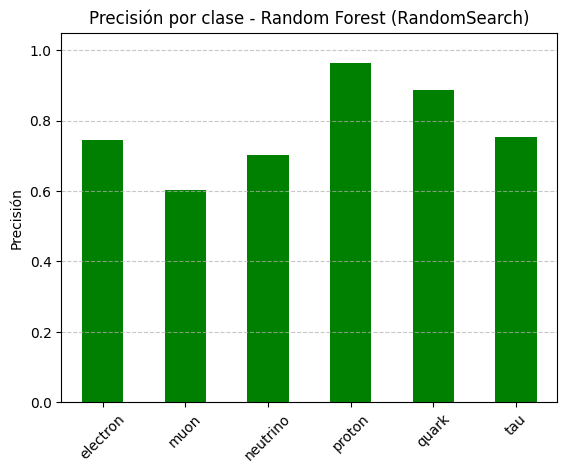

In [8]:
print("--- Precisión por Clase (Random Forest) ---")
report_rf_dict = classification_report(y_test, y_pred_rf, output_dict=True, target_names=classes)
df_rf = pd.DataFrame(report_rf_dict).transpose()

df_rf.loc[classes, "precision"].plot(kind="bar", color="green")
plt.title("Precisión por clase - Random Forest (RandomSearch)")
plt.ylabel("Precisión")
plt.ylim(0, 1.05); plt.xticks(rotation=45); plt.grid(axis='y', linestyle='--', alpha=0.7); plt.show()

--- Curvas ROC (Random Forest) ---


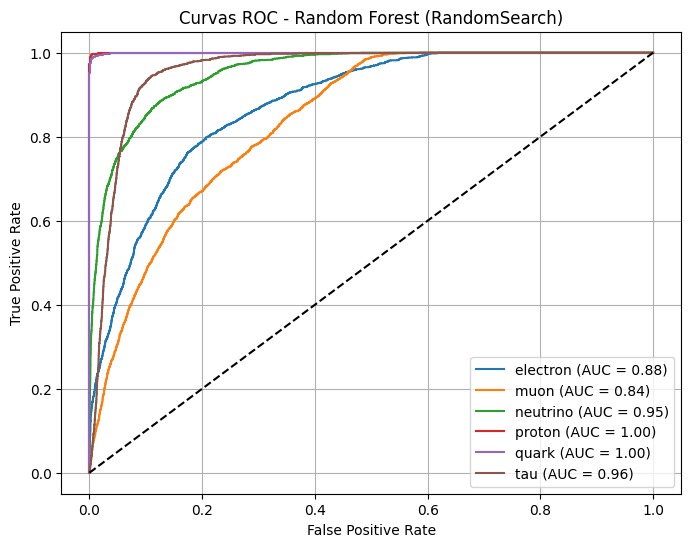

In [9]:
print("--- Curvas ROC (Random Forest) ---")
y_score_rf = best_rf.predict_proba(X_test)
plot_multiclass_roc(y_test_bin, y_score_rf, classes, "Curvas ROC - Random Forest (RandomSearch)")

--- Curva de Aprendizaje (Random Forest) ---


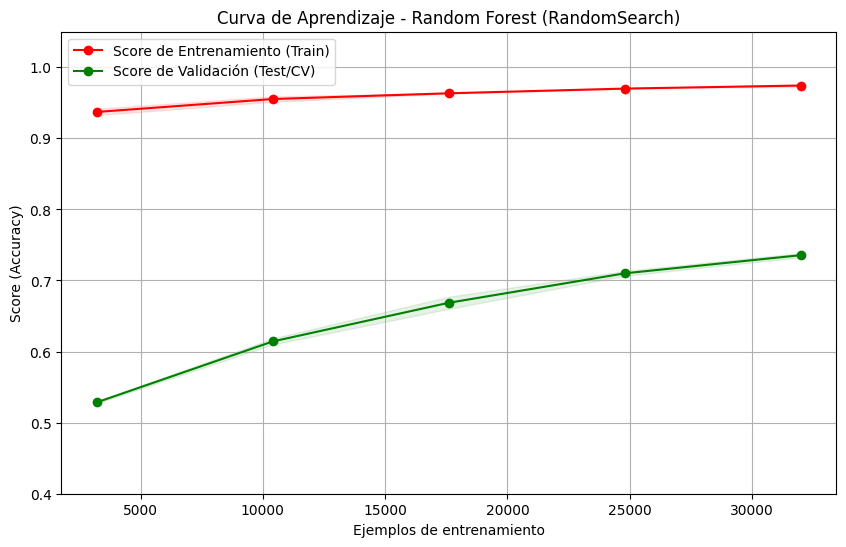

In [10]:
print("--- Curva de Aprendizaje (Random Forest) ---")
plot_learning_curve(best_rf, "Curva de Aprendizaje - Random Forest (RandomSearch)", X_train, y_train, cv=3, ylim=(0.4, 1.05))